In [ ]:
library(nnet)       # For multinom()
library(ggplot2)    # For visualization
library(dplyr)      # For data manipulation
library(ggeffects)  # For calculating predicted probabilities
library(readxl)
library(writexl)
library(car)
library(MASS)  # Untuk regresi ordinal (fungsi polr)
library(ggeffects)
library(ggplot2)
library(scales) # Untuk format persentase
library(knitr)
library(brant)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘ggeffects’ was built under R version 4.3.3”
Warning message:
“package ‘car’ was built under R version 4.3.3”
Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode



Attaching package: ‘MASS’


The following object is masked from ‘package:dplyr’:

    select




In [ ]:
df_male <- read_excel("../data/processed/male.xlsx")
head(df_male)

citra_tubuh,aktivitas_fisik,gizi_seimbang,citra_tubuh_cat,aktivitas_fisik_cat,gizi_seimbang_cat
<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
3,3,3,Sedang,Sedang,Sedang
3,3,3,Sedang,Sedang,Sedang
3,3,4,Sedang,Sedang,Tinggi
3,2,3,Sedang,Rendah,Sedang
3,3,3,Sedang,Sedang,Sedang
3,3,3,Sedang,Sedang,Sedang


In [ ]:
# Memastikan Y adalah faktor berurut (ordered factor)
df_male$citra_tubuh_cat <- factor(df_male$citra_tubuh_cat, 
                               levels = c("Rendah", "Sedang", "Tinggi"), 
                               ordered = TRUE)

# Mengubah variabel X menjadi faktor berurut (sama seperti Y)
df_male$aktivitas_fisik_cat <- factor(df_male$aktivitas_fisik_cat, 
                                   levels = c("Rendah", "Sedang", "Tinggi"), 
                                   ordered = TRUE)

df_male$gizi_seimbang_cat <- factor(df_male$gizi_seimbang_cat, 
                                 levels = c("Rendah", "Sedang", "Tinggi"), 
                                 ordered = TRUE)

## 1) Analisis Deskriptif

In [ ]:
summary(df_male[, c("aktivitas_fisik_cat", "gizi_seimbang_cat", "citra_tubuh_cat")])

 aktivitas_fisik_cat gizi_seimbang_cat citra_tubuh_cat
 Rendah:224          Rendah:141        Rendah: 79     
 Sedang:469          Sedang:532        Sedang:586     
 Tinggi:100          Tinggi:120        Tinggi:128     

## 2) Menjalankan Regresi Logistik Menggunakan Package MASS

In [ ]:
# Membuat model
# Argumen Hess = TRUE diperlukan untuk menghitung p-value nantinya
model_ordinal_male <- polr(citra_tubuh_cat ~ aktivitas_fisik_cat + gizi_seimbang_cat, 
                      data = df_male, 
                      Hess = TRUE)

# Melihat ringkasan awal model
summary(model_ordinal_male)

Call:
polr(formula = citra_tubuh_cat ~ aktivitas_fisik_cat + gizi_seimbang_cat, 
    data = df_male, Hess = TRUE)

Coefficients:
                         Value Std. Error t value
aktivitas_fisik_cat.L  0.88739     0.2085  4.2567
aktivitas_fisik_cat.Q  0.04259     0.1411  0.3019
gizi_seimbang_cat.L    1.57983     0.2262  6.9846
gizi_seimbang_cat.Q   -0.24831     0.1423 -1.7453

Intercepts:
              Value    Std. Error t value 
Rendah|Sedang  -2.5559   0.1491   -17.1401
Sedang|Tinggi   1.8373   0.1271    14.4538

Residual Deviance: 1079.688 
AIC: 1091.688 

### 2.1 Menguji Asumsi Proportional Odds (Uji Brant)
Regresi logistik ordinal didasarkan pada asumsi proportional odds atau asumsi paralel, yang menyatakan bahwa pengaruh variabel independen tetap konsisten di setiap ambang batas kategori (misal: pengaruh X terhadap "Rendah ke Sedang" sama dengan "Sedang ke Tinggi").

**Cara membaca hasil Uji Brant**:

- Perhatikan nilai p-value (biasanya kolom Probability pada output uji Brant).
- Jika p-value > 0.05: Asumsi Proportional Odds terpenuhi. Data terbukti valid untuk regresi ordinal, dan bisa lanjut menginterpretasi nilai koefisien/Odds Ratio.
- Jika p-value < 0.05: Asumsi dilanggar. Model polr ini tidak valid. Anda harus beralih menggunakan regresi multinomial biasa atau regresi probit.

In [ ]:
# Melakukan Uji Brant
brant(model_ordinal_male)

---------------------------------------------------- 
Test for		X2	df	probability 
---------------------------------------------------- 
Omnibus			8.26	4	0.08
aktivitas_fisik_cat.L	0.03	1	0.87
aktivitas_fisik_cat.Q	1.51	1	0.22
gizi_seimbang_cat.L	2.41	1	0.12
gizi_seimbang_cat.Q	2.85	1	0.09
---------------------------------------------------- 

H0: Parallel Regression Assumption holds


Warning message in brant(model_ordinal_male):
“1 combinations in table(dv,ivs) do not occur. Because of that, the test results might be invalid.”


In [ ]:
table(df_male$aktivitas_fisik_cat, df_male$citra_tubuh_cat)

        
         Rendah Sedang Tinggi
  Rendah     45    160     19
  Sedang     30    364     75
  Tinggi      4     62     34

In [ ]:
table(df_male$gizi_seimbang_cat, df_male$citra_tubuh_cat)

        
         Rendah Sedang Tinggi
  Rendah     40     96      5
  Sedang     32    420     80
  Tinggi      7     70     43

In [ ]:
# 1. Menghitung p-value dari t-value
ctable <- coef(summary(model_ordinal_male))
p <- pnorm(abs(ctable[, "t value"]), lower.tail = FALSE) * 2
ctable <- cbind(ctable, "p value" = p)
print(ctable)

# 2. Menghitung Odds Ratio (OR) dan Confidence Interval
# OR sangat penting untuk interpretasi regresi logistik/ordinal
ci <- confint(model_ordinal_male)
exp(cbind(OR = coef(model_ordinal_male), ci))

                            Value Std. Error     t value      p value
aktivitas_fisik_cat.L  0.88738809  0.2084697   4.2566769 2.074879e-05
aktivitas_fisik_cat.Q  0.04259061  0.1410979   0.3018515 7.627653e-01
gizi_seimbang_cat.L    1.57983239  0.2261883   6.9845906 2.856878e-12
gizi_seimbang_cat.Q   -0.24831426  0.1422741  -1.7453236 8.092856e-02
Rendah|Sedang         -2.55589574  0.1491180 -17.1400933 7.453102e-66
Sedang|Tinggi          1.83731846  0.1271168  14.4537790 2.373008e-47


Waiting for profiling to be done...



,OR,2.5 %,97.5 %
aktivitas_fisik_cat.L,2.4287776,1.6152209,3.659628
aktivitas_fisik_cat.Q,1.0435106,0.7903019,1.374772
gizi_seimbang_cat.L,4.8541422,3.1211831,7.578845
gizi_seimbang_cat.Q,0.7801147,0.5889734,1.029309


In [ ]:
vif(model_ordinal_male)

,GVIF,Df,GVIF^(1/(2*Df))
aktivitas_fisik_cat,1.156332,2,1.036981
gizi_seimbang_cat,1.156332,2,1.036981


In [ ]:
library(generalhoslem)
lipsitz.test(model_ordinal_male)


	Lipsitz goodness of fit test for ordinal response models

data:  formula:  citra_tubuh_cat ~ aktivitas_fisik_cat + gizi_seimbang_cat
LR statistic = 11.87, df = 9, p-value = 0.2207


In [ ]:
library(DescTools)
PseudoR2(model_ordinal_male, which = c("McFadden", "Nagelkerke"))

McFadden Nagelkerke 
0.08951006 0.16147714

Esktrak hasil regresi dan menyimpannya ke dalam tabel yang rapi:

In [ ]:
# 1. Mengekstrak tabel koefisien dasar dari model
tabel_koef <- coef(summary(model_ordinal_male))

# 2. Menghitung P-Value secara manual dari nilai distribusi normal standar (Z/T)
p_values <- pnorm(abs(tabel_koef[, "t value"]), lower.tail = FALSE) * 2

# 3. Menghitung Confidence Interval (CI) dan Odds Ratio (OR) untuk prediktor
# Proses confint() mungkin memakan waktu beberapa detik karena melakukan iterasi profil
ci_prediktor <- confint(model_ordinal_male)
or_prediktor <- exp(coef(model_ordinal_male))
ci_or_prediktor <- exp(ci_prediktor)

# 4. Menyusun Data Frame untuk Variabel Prediktor (Aktivitas Fisik & Gizi)
# Baris 1 sampai 4 pada tabel_koef adalah prediktor kita
tabel_prediktor <- data.frame(
  Kategori      = rownames(tabel_koef)[1:4],
  Koef_Logit    = round(tabel_koef[1:4, "Value"], 4),
  Std_Error     = round(tabel_koef[1:4, "Std. Error"], 4),
  T_Value       = round(tabel_koef[1:4, "t value"], 4),
  P_Value       = signif(p_values[1:4], 4), # Menggunakan signif untuk notasi ilmiah jika sangat kecil
  Odds_Ratio    = round(or_prediktor, 4),
  CI_95_Bawah   = round(ci_or_prediktor[, 1], 4),
  CI_95_Atas    = round(ci_or_prediktor[, 2], 4)
)

# 5. Menyusun Data Frame untuk Threshold / Intercept
# Baris 5 dan 6 adalah threshold (Rendah|Sedang, Sedang|Tinggi)
# Threshold tidak memerlukan interpretasi Odds Ratio dalam pelaporan standar
tabel_threshold <- data.frame(
  Kategori      = rownames(tabel_koef)[5:6],
  Koef_Logit    = round(tabel_koef[5:6, "Value"], 4),
  Std_Error     = round(tabel_koef[5:6, "Std. Error"], 4),
  T_Value       = round(tabel_koef[5:6, "t value"], 4),
  P_Value       = signif(p_values[5:6], 4),
  Odds_Ratio    = NA,
  CI_95_Bawah   = NA,
  CI_95_Atas    = NA
)

# 6. Menggabungkan Keduanya Menjadi Satu Tabel Final yang Rapih
tabel_hasil_final <- rbind(tabel_prediktor, tabel_threshold)
rownames(tabel_hasil_final) <- NULL # Menghapus nama baris agar lebih bersih

# Menampilkan hasil
print(tabel_hasil_final)

Waiting for profiling to be done...



               Kategori Koef_Logit Std_Error  T_Value   P_Value Odds_Ratio
1 aktivitas_fisik_cat.L     0.8874    0.2085   4.2567 2.075e-05     2.4288
2 aktivitas_fisik_cat.Q     0.0426    0.1411   0.3019 7.628e-01     1.0435
3   gizi_seimbang_cat.L     1.5798    0.2262   6.9846 2.857e-12     4.8541
4   gizi_seimbang_cat.Q    -0.2483    0.1423  -1.7453 8.093e-02     0.7801
5         Rendah|Sedang    -2.5559    0.1491 -17.1401 7.453e-66         NA
6         Sedang|Tinggi     1.8373    0.1271  14.4538 2.373e-47         NA
  CI_95_Bawah CI_95_Atas
1      1.6152     3.6596
2      0.7903     1.3748
3      3.1212     7.5788
4      0.5890     1.0293
5          NA         NA
6          NA         NA


In [ ]:
# Menyimpan tabel ke dalam format CSV agar mudah dibuka di Excel
write_xlsx(tabel_hasil_final, "../report/excel_output/Hasil_Regresi_Ordinal_male.xlsx")

Waiting for profiling to be done...



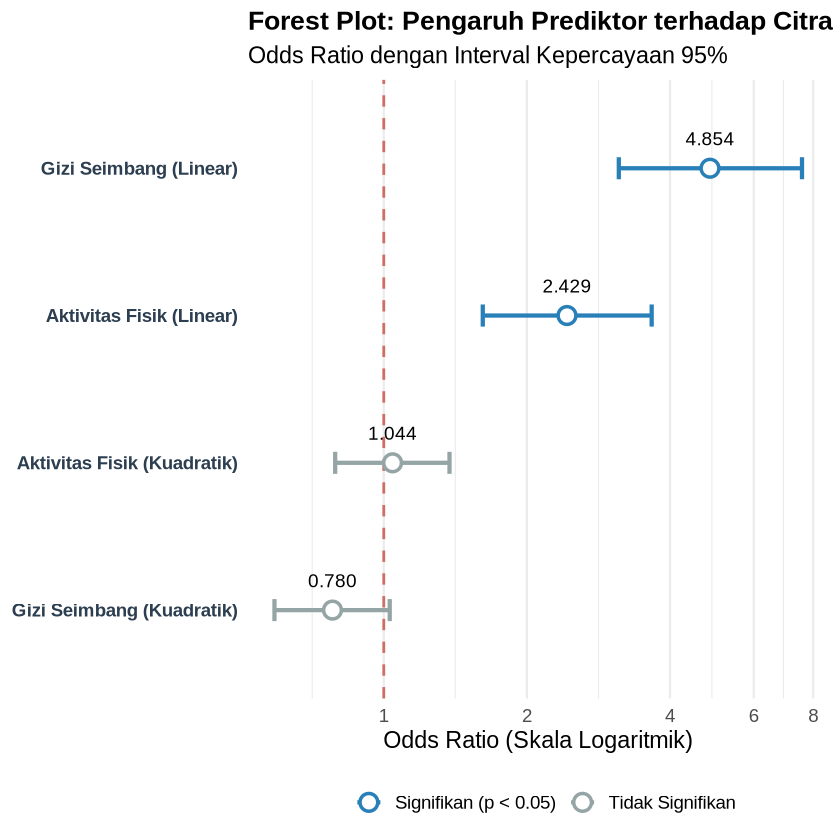

In [ ]:
# --- FASE 1: EKSTRAKSI OTOMATIS DARI model_ordinal_male ---

# Mengambil tabel ringkasan
tabel_koef <- coef(summary(model_ordinal_male))

# Menghitung P-Value secara dinamis
p_values <- pnorm(abs(tabel_koef[, "t value"]), lower.tail = FALSE) * 2

# Menghitung OR dan CI (Akan memunculkan tulisan "Waiting for profiling...", ini normal)
or_val <- exp(coef(model_ordinal_male))
ci_val <- exp(confint(model_ordinal_male))

# Menyusun Data Frame khusus untuk prediktor (baris 1 sampai 4)
df_plot <- data.frame(
  Prediktor = rownames(tabel_koef)[1:4],
  OR = or_val,
  CI_Bawah = ci_val[, 1],
  CI_Atas = ci_val[, 2],
  P_Value = p_values[1:4]
)

# Merapikan label nama variabel untuk keperluan plot
df_plot$Label_Rapi <- c("Aktivitas Fisik (Linear)", 
                        "Aktivitas Fisik (Kuadratik)", 
                        "Gizi Seimbang (Linear)", 
                        "Gizi Seimbang (Kuadratik)")

# Membuat kolom penanda signifikansi berdasarkan P-Value
df_plot$Signifikansi <- ifelse(df_plot$P_Value < 0.05, 
                               "Signifikan (p < 0.05)", 
                               "Tidak Signifikan")

# --- FASE 2: MEMBUAT FOREST PLOT SAINTIFIK ---

plot_forest <- ggplot(df_plot, aes(x = reorder(Label_Rapi, OR), y = OR, color = Signifikansi)) +
  # Garis referensi nol-efek di angka 1
  geom_hline(yintercept = 1, linetype = "dashed", color = "#c0392b", size = 0.8, alpha = 0.7) +
  # Titik estimasi dan rentang error
  geom_errorbar(aes(ymin = CI_Bawah, ymax = CI_Atas), width = 0.15, size = 1.2) +
  geom_point(size = 4, shape = 21, fill = "white", stroke = 1.5) +
  geom_text(aes(label = sprintf("%.3f", OR)), 
            nudge_x = 0.2,        # Menggeser teks sedikit ke atas bulatan
            color = "black",       # Menimpa warna default agar angka tetap hitam dan tegas
            #fontface = "bold",     # Cetak tebal
            size = 4,            # Ukuran font angka
            show.legend = FALSE) + # Mencegah huruf 'a' muncul di dalam legend
  coord_flip() + # Memutar plot agar label mudah dibaca
  # Skala sumbu Y dibuat logaritmik agar jarak 0.5 ke 1 sama dengan 1 ke 2
  scale_y_log10(breaks = c(0.5, 1, 2, 4, 6, 8)) +
  # Pemilihan warna: Biru Baja untuk signifikan, Abu-abu untuk yang tidak
  scale_color_manual(values = c("Signifikan (p < 0.05)" = "#2980b9", 
                                "Tidak Signifikan" = "#95a5a6")) +
  labs(title = "Forest Plot: Pengaruh Prediktor terhadap Citra Tubuh",
       subtitle = "Odds Ratio dengan Interval Kepercayaan 95%",
       x = NULL, # Tidak perlu judul sumbu X karena label sudah jelas
       y = "Odds Ratio (Skala Logaritmik)") +
  # Tema visual yang bersih
  theme_minimal(base_family = "sans", base_size = 14) +
  theme(legend.position = "bottom",
        legend.title = element_blank(),
        panel.grid.major.y = element_blank(), # Membuang garis horizontal yang mengganggu
        plot.title = element_text(face = "bold", size = 16),
        axis.text.y = element_text(face = "bold", color = "#2c3e50"))

# Menampilkan plot
print(plot_forest)

In [ ]:
ggsave("../report/visualization/forest_plot_male.jpg", plot = plot_forest, width = 10, height = 6, units = "in", dpi = 1200)

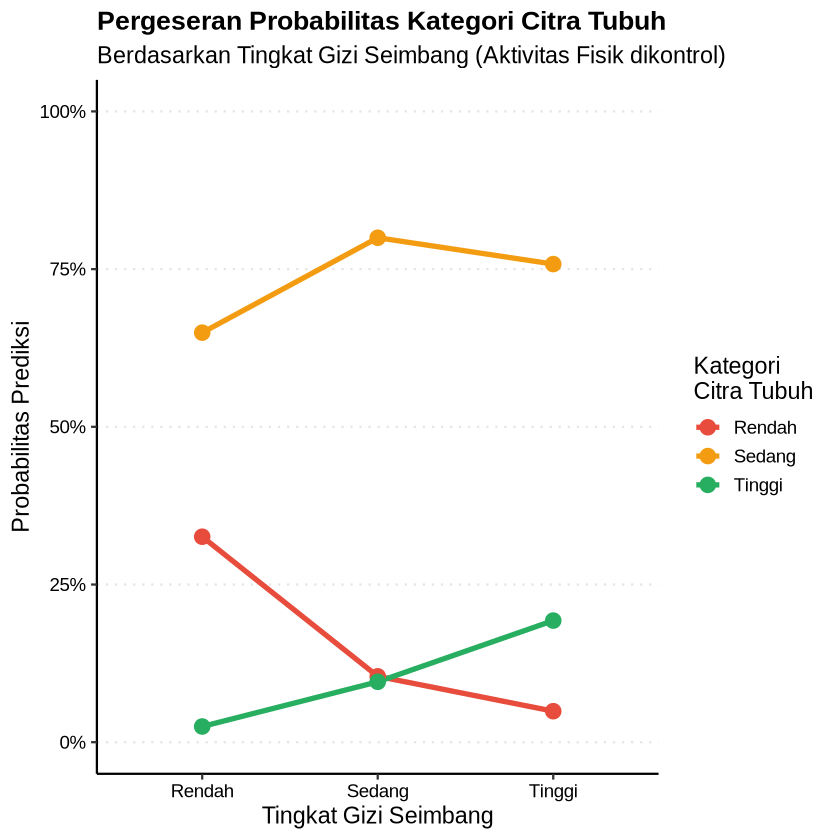

In [ ]:
# --- FASE 2: MEMBUAT PROBABILITY PLOT SAINTIFIK ---
plot_prob <- ggplot(pred_gizi, aes(x = x, y = predicted, group = response.level, color = response.level)) +
  geom_line(size = 1.5) +
  geom_point(size = 4) +
  # Sumbu Y diformat menjadi persentase agar lebih intuitif
  scale_y_continuous(labels = percent_format(accuracy = 1), limits = c(0, 1)) +
  # Palet warna lalu lintas (Merah=Rendah, Kuning=Sedang, Hijau=Tinggi)
  scale_color_manual(values = c("Rendah" = "#e74c3c", 
                                "Sedang" = "#f39c12", 
                                "Tinggi" = "#27ae60")) +
  labs(title = "Pergeseran Probabilitas Kategori Citra Tubuh",
       subtitle = "Berdasarkan Tingkat Gizi Seimbang (Aktivitas Fisik dikontrol)",
       x = "Tingkat Gizi Seimbang",
       y = "Probabilitas Prediksi",
       color = "Kategori\nCitra Tubuh") +
  theme_classic(base_family = "sans", base_size = 14) +
  theme(plot.title = element_text(face = "bold", size = 16),
        panel.grid.major.y = element_line(color = "grey90", linetype = "dotted"),
        legend.position = "right",
        axis.text = element_text(color = "black"))

# Menampilkan plot
print(plot_prob)

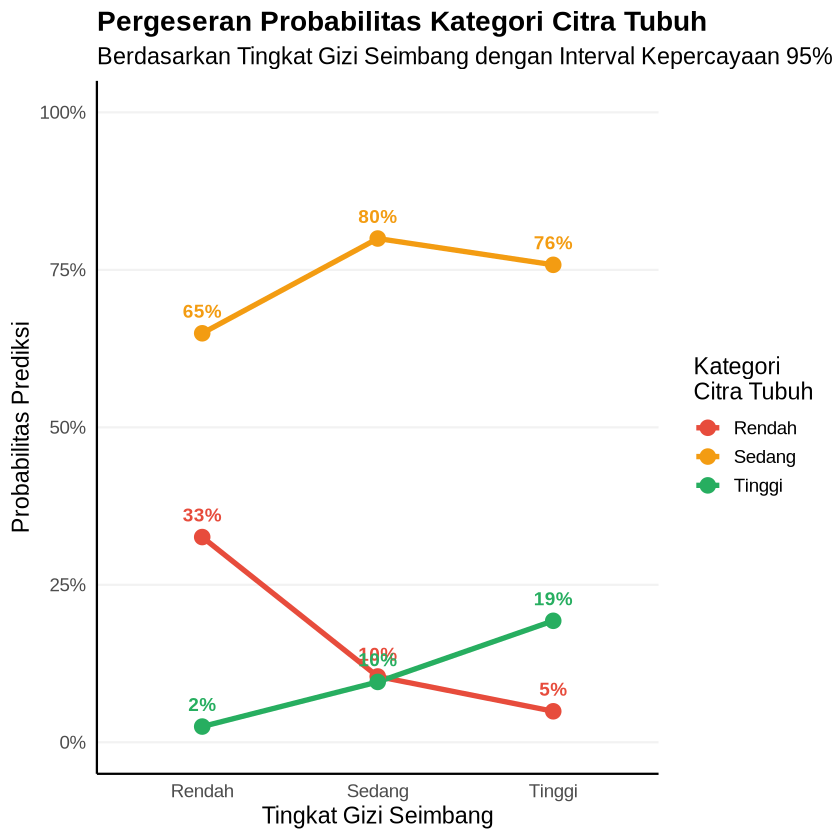

In [ ]:
library(scales) # Pastikan paket ini aktif untuk fungsi percent()

plot_prob_revisi <- ggplot(pred_gizi, aes(x = x, y = predicted, group = response.level, color = response.level)) +
  
  # 1. Menambahkan Pita Interval Kepercayaan (Confidence Interval)
  # Diletakkan paling atas agar tidak menutupi garis dan titik
  geom_ribbon(aes(ymin = conf.low, ymax = conf.high, fill = response.level), 
              alpha = 0.15, color = NA, show.legend = FALSE) +
  
  geom_line(size = 1.5) +
  geom_point(size = 4) +
  
  # 2. Menambahkan Teks Persentase Eksak
  geom_text(aes(label = percent(predicted, accuracy = 1)), 
            vjust = -1.2, # Mendorong teks ke atas titik
            size = 4, 
            fontface = "bold", 
            show.legend = FALSE) +
  
  scale_y_continuous(labels = percent_format(accuracy = 1), limits = c(0, 1)) +
  scale_color_manual(values = c("Rendah" = "#e74c3c", "Sedang" = "#f39c12", "Tinggi" = "#27ae60")) +
  scale_fill_manual(values = c("Rendah" = "#e74c3c", "Sedang" = "#f39c12", "Tinggi" = "#27ae60")) +
  
  labs(title = "Pergeseran Probabilitas Kategori Citra Tubuh",
       subtitle = "Berdasarkan Tingkat Gizi Seimbang dengan Interval Kepercayaan 95%",
       x = "Tingkat Gizi Seimbang",
       y = "Probabilitas Prediksi",
       color = "Kategori\nCitra Tubuh") +
  theme_minimal(base_size = 14) +
  theme(panel.grid.major.x = element_blank(), 
        panel.grid.minor = element_blank(),   
        panel.grid.major.y = element_line(color = "grey95"), 
        panel.background = element_rect(fill = "white", color = NA),
        plot.background = element_rect(fill = "white", color = NA),
        axis.line.x = element_line(color = "black"),
        axis.line.y = element_line(color = "black"),
        plot.title = element_text(face = "bold"))

print(plot_prob_revisi)

In [ ]:
ggsave("../report/visualization/prob_plot_male.jpg", plot = plot_prob, width = 10, height = 6, units = "in", dpi = 1200)

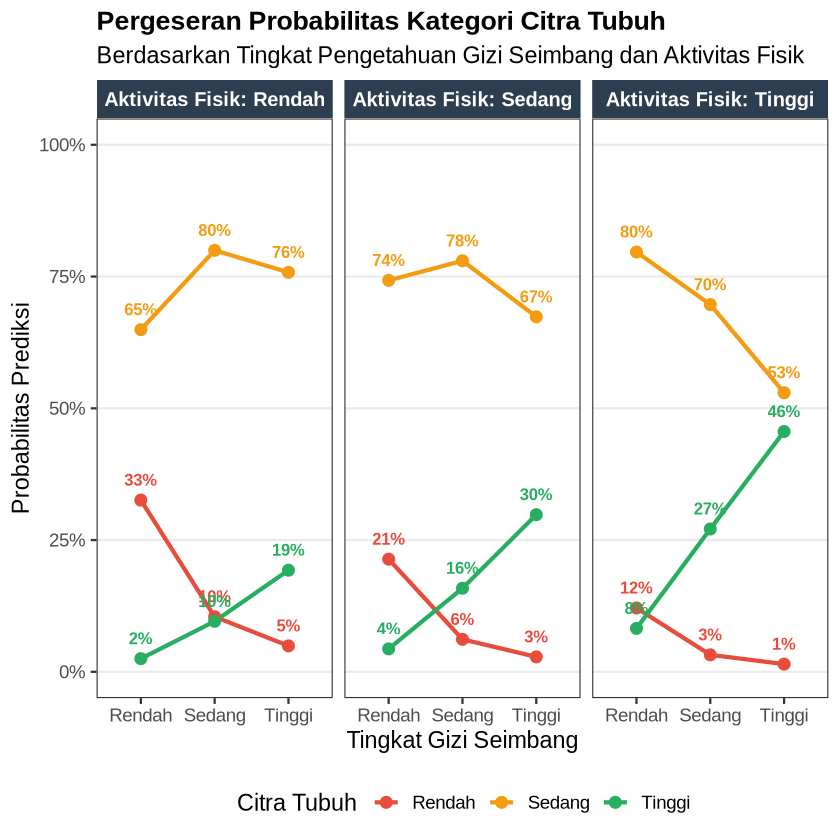

In [ ]:
library(ggeffects)
library(ggplot2)
library(scales)

# 1. Memprediksi dengan DUA variabel sekaligus
# Variabel pertama (gizi) akan menjadi sumbu X (kolom 'x')
# Variabel kedua (aktivitas) akan disimpan oleh ggeffects di kolom bernama 'group'
pred_gabungan <- ggpredict(model_ordinal_male, terms = c("gizi_seimbang_cat", "aktivitas_fisik_cat"))

# 2. Membuat Plot Gabungan (Faceted Plot)
plot_gabungan <- ggplot(pred_gabungan, aes(x = x, y = predicted, color = response.level, group = response.level)) +
  
  # Garis, Titik, dan Pita Interval
  geom_ribbon(aes(ymin = conf.low, ymax = conf.high, fill = response.level), 
              alpha = 0.1, color = NA, show.legend = FALSE) +
  geom_line(size = 1.2) +
  geom_point(size = 3) +
  
  # Label angka persentase
  geom_text(aes(label = percent(predicted, accuracy = 1)), 
            vjust = -1.2, size = 3.5, fontface = "bold", show.legend = FALSE) +
  
  # KUNCI UTAMA: Memecah plot berdasarkan Aktivitas Fisik (yang disimpan di kolom 'group')
  facet_wrap(~ group, labeller = labeller(group = function(x) paste("Aktivitas Fisik:", x))) +
  
  # Formatting Skala & Warna
  scale_y_continuous(labels = percent_format(accuracy = 1), limits = c(0, 1)) +
  scale_color_manual(values = c("Rendah" = "#e74c3c", "Sedang" = "#f39c12", "Tinggi" = "#27ae60")) +
  scale_fill_manual(values = c("Rendah" = "#e74c3c", "Sedang" = "#f39c12", "Tinggi" = "#27ae60")) +
  
  # Label & Tema
  labs(title = "Pergeseran Probabilitas Kategori Citra Tubuh",
       subtitle = "Berdasarkan Tingkat Pengetahuan Gizi Seimbang dan Aktivitas Fisik",
       x = "Tingkat Gizi Seimbang",
       y = "Probabilitas Prediksi",
       color = "Citra Tubuh") +
  # theme_bw (Black & White) sangat cocok untuk grafik berpanel (facet)
  theme_bw(base_size = 14) +
  theme(panel.grid.major.x = element_blank(),
        panel.grid.minor = element_blank(),
        strip.background = element_rect(fill = "#2c3e50", color = NA), # Latar belakang judul panel
        strip.text = element_text(color = "white", face = "bold", size = 12), # Teks judul panel
        plot.title = element_text(face = "bold", size = 16),
        legend.position = "bottom")

print(plot_gabungan)

In [ ]:
ggsave("../report/visualization/prob_plot_male.jpg", plot = plot_gabungan, width = 10, height = 6, units = "in", dpi = 1200)

## PEREMPUAN

In [ ]:
df_female <- read_excel("../data/processed/female.xlsx")
head(df_female)

citra_tubuh,aktivitas_fisik,gizi_seimbang,citra_tubuh_cat,aktivitas_fisik_cat,gizi_seimbang_cat
<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
3,3,3,Sedang,Sedang,Sedang
3,3,3,Sedang,Sedang,Sedang
3,3,2,Sedang,Sedang,Rendah
3,3,3,Sedang,Sedang,Sedang
3,3,3,Sedang,Sedang,Sedang
3,3,4,Sedang,Sedang,Tinggi


In [ ]:
# Memastikan Y adalah faktor berurut (ordered factor)
df_female$citra_tubuh_cat <- factor(df_female$citra_tubuh_cat, 
                               levels = c("Rendah", "Sedang", "Tinggi"), 
                               ordered = TRUE)

# Mengubah variabel X menjadi faktor berurut (sama seperti Y)
df_female$aktivitas_fisik_cat <- factor(df_female$aktivitas_fisik_cat, 
                                   levels = c("Rendah", "Sedang", "Tinggi"), 
                                   ordered = TRUE)

df_female$gizi_seimbang_cat <- factor(df_female$gizi_seimbang_cat, 
                                 levels = c("Rendah", "Sedang", "Tinggi"), 
                                 ordered = TRUE)

## ANALISIS DESKRIPTIF

In [ ]:
summary(df_female[, c("aktivitas_fisik_cat", "gizi_seimbang_cat", "citra_tubuh_cat")])

 aktivitas_fisik_cat gizi_seimbang_cat citra_tubuh_cat
 Rendah:212          Rendah:126        Rendah: 66     
 Sedang:484          Sedang:553        Sedang:613     
 Tinggi: 84          Tinggi:101        Tinggi:101     

## REGRESI LOGISTIK PEREMPUAN

In [ ]:
# Membuat model
# Argumen Hess = TRUE diperlukan untuk menghitung p-value nantinya
model_ordinal_female <- polr(citra_tubuh_cat ~ aktivitas_fisik_cat + gizi_seimbang_cat, 
                      data = df_female, 
                      Hess = TRUE)

# Melihat ringkasan awal model
summary(model_ordinal_female)

Call:
polr(formula = citra_tubuh_cat ~ aktivitas_fisik_cat + gizi_seimbang_cat, 
    data = df_female, Hess = TRUE)

Coefficients:
                       Value Std. Error t value
aktivitas_fisik_cat.L 1.3982     0.2283  6.1244
aktivitas_fisik_cat.Q 0.3916     0.1510  2.5927
gizi_seimbang_cat.L   1.3533     0.2467  5.4855
gizi_seimbang_cat.Q   0.1066     0.1540  0.6925

Intercepts:
              Value    Std. Error t value 
Rendah|Sedang  -3.0068   0.1652   -18.2065
Sedang|Tinggi   1.8037   0.1416    12.7396

Residual Deviance: 935.9594 
AIC: 947.9594 

In [ ]:
brant(model_ordinal_female)

---------------------------------------------------- 
Test for		X2	df	probability 
---------------------------------------------------- 
Omnibus			2.9	4	0.58
aktivitas_fisik_cat.L	0.12	1	0.73
aktivitas_fisik_cat.Q	0.39	1	0.53
gizi_seimbang_cat.L	0.56	1	0.45
gizi_seimbang_cat.Q	0.11	1	0.75
---------------------------------------------------- 

H0: Parallel Regression Assumption holds


Warning message in brant(model_ordinal_female):
“7 combinations in table(dv,ivs) do not occur. Because of that, the test results might be invalid.”


In [ ]:
# 1. Menghitung p-value dari t-value
ctable <- coef(summary(model_ordinal_female))
p <- pnorm(abs(ctable[, "t value"]), lower.tail = FALSE) * 2
ctable <- cbind(ctable, "p value" = p)
print(ctable)

# 2. Menghitung Odds Ratio (OR) dan Confidence Interval
# OR sangat penting untuk interpretasi regresi logistik/ordinal
ci <- confint(model_ordinal_female)
exp(cbind(OR = coef(model_ordinal_female), ci))

                           Value Std. Error     t value      p value
aktivitas_fisik_cat.L  1.3981972  0.2282978   6.1244451 9.100016e-10
aktivitas_fisik_cat.Q  0.3915954  0.1510398   2.5926639 9.523579e-03
gizi_seimbang_cat.L    1.3533170  0.2467068   5.4855270 4.122387e-08
gizi_seimbang_cat.Q    0.1066322  0.1539715   0.6925449 4.885952e-01
Rendah|Sedang         -3.0068459  0.1651525 -18.2064849 4.584528e-74
Sedang|Tinggi          1.8037068  0.1415824  12.7396251 3.561021e-37


Waiting for profiling to be done...



,OR,2.5 %,97.5 %
aktivitas_fisik_cat.L,4.047896,2.5901330,6.345108
aktivitas_fisik_cat.Q,1.479339,1.1003944,1.990627
gizi_seimbang_cat.L,3.870242,2.3860887,6.278847
gizi_seimbang_cat.Q,1.112525,0.8227302,1.505550


In [ ]:
vif(model_ordinal_female)

,GVIF,Df,GVIF^(1/(2*Df))
aktivitas_fisik_cat,1.079948,2,1.019414
gizi_seimbang_cat,1.079948,2,1.019414


In [ ]:
library(generalhoslem)
lipsitz.test(model_ordinal_female)

Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”



	Lipsitz goodness of fit test for ordinal response models

data:  formula:  citra_tubuh_cat ~ aktivitas_fisik_cat + gizi_seimbang_cat
LR statistic = 6.7955, df = 9, p-value = 0.6584


In [ ]:
library(DescTools)
PseudoR2(model_ordinal_female, which = c("McFadden", "Nagelkerke"))

McFadden Nagelkerke 
0.09507445 0.16126958

In [ ]:
# 1. Mengekstrak tabel koefisien dasar dari model
tabel_koef <- coef(summary(model_ordinal_female))

# 2. Menghitung P-Value secara manual dari nilai distribusi normal standar (Z/T)
p_values <- pnorm(abs(tabel_koef[, "t value"]), lower.tail = FALSE) * 2

# 3. Menghitung Confidence Interval (CI) dan Odds Ratio (OR) untuk prediktor
# Proses confint() mungkin memakan waktu beberapa detik karena melakukan iterasi profil
ci_prediktor <- confint(model_ordinal_female)
or_prediktor <- exp(coef(model_ordinal_female))
ci_or_prediktor <- exp(ci_prediktor)

# 4. Menyusun Data Frame untuk Variabel Prediktor (Aktivitas Fisik & Gizi)
# Baris 1 sampai 4 pada tabel_koef adalah prediktor kita
tabel_prediktor <- data.frame(
  Kategori      = rownames(tabel_koef)[1:4],
  Koef_Logit    = round(tabel_koef[1:4, "Value"], 4),
  Std_Error     = round(tabel_koef[1:4, "Std. Error"], 4),
  T_Value       = round(tabel_koef[1:4, "t value"], 4),
  P_Value       = signif(p_values[1:4], 4), # Menggunakan signif untuk notasi ilmiah jika sangat kecil
  Odds_Ratio    = round(or_prediktor, 4),
  CI_95_Bawah   = round(ci_or_prediktor[, 1], 4),
  CI_95_Atas    = round(ci_or_prediktor[, 2], 4)
)

# 5. Menyusun Data Frame untuk Threshold / Intercept
# Baris 5 dan 6 adalah threshold (Rendah|Sedang, Sedang|Tinggi)
# Threshold tidak memerlukan interpretasi Odds Ratio dalam pelaporan standar
tabel_threshold <- data.frame(
  Kategori      = rownames(tabel_koef)[5:6],
  Koef_Logit    = round(tabel_koef[5:6, "Value"], 4),
  Std_Error     = round(tabel_koef[5:6, "Std. Error"], 4),
  T_Value       = round(tabel_koef[5:6, "t value"], 4),
  P_Value       = signif(p_values[5:6], 4),
  Odds_Ratio    = NA,
  CI_95_Bawah   = NA,
  CI_95_Atas    = NA
)

# 6. Menggabungkan Keduanya Menjadi Satu Tabel Final yang Rapih
tabel_hasil_female <- rbind(tabel_prediktor, tabel_threshold)
rownames(tabel_hasil_final) <- NULL # Menghapus nama baris agar lebih bersih

# Menampilkan hasil
print(tabel_hasil_female)

Waiting for profiling to be done...



                                   Kategori Koef_Logit Std_Error  T_Value
aktivitas_fisik_cat.L aktivitas_fisik_cat.L     1.3982    0.2283   6.1244
aktivitas_fisik_cat.Q aktivitas_fisik_cat.Q     0.3916    0.1510   2.5927
gizi_seimbang_cat.L     gizi_seimbang_cat.L     1.3533    0.2467   5.4855
gizi_seimbang_cat.Q     gizi_seimbang_cat.Q     0.1066    0.1540   0.6925
Rendah|Sedang                 Rendah|Sedang    -3.0068    0.1652 -18.2065
Sedang|Tinggi                 Sedang|Tinggi     1.8037    0.1416  12.7396
                        P_Value Odds_Ratio CI_95_Bawah CI_95_Atas
aktivitas_fisik_cat.L 9.100e-10     4.0479      2.5901     6.3451
aktivitas_fisik_cat.Q 9.524e-03     1.4793      1.1004     1.9906
gizi_seimbang_cat.L   4.122e-08     3.8702      2.3861     6.2788
gizi_seimbang_cat.Q   4.886e-01     1.1125      0.8227     1.5055
Rendah|Sedang         4.585e-74         NA          NA         NA
Sedang|Tinggi         3.561e-37         NA          NA         NA


In [ ]:
# Menyimpan tabel ke dalam format CSV agar mudah dibuka di Excel
write_xlsx(tabel_hasil_female, "../report/excel_output/Hasil_Regresi_Ordinal_female.xlsx")

Waiting for profiling to be done...



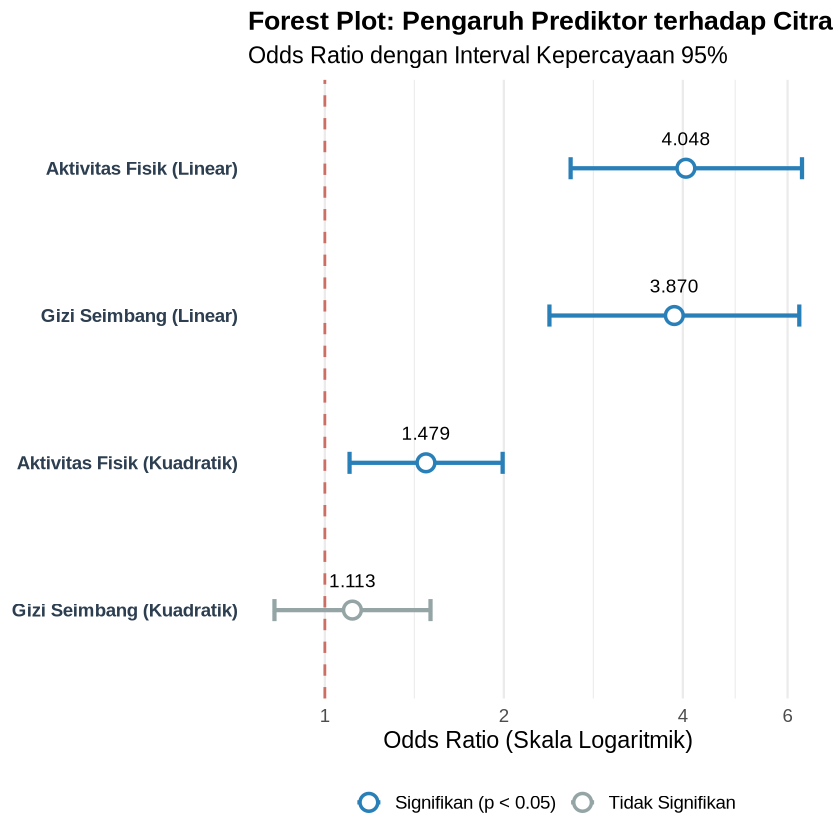

In [ ]:
# --- FASE 1: EKSTRAKSI OTOMATIS DARI model_ordinal_male ---

# Mengambil tabel ringkasan
tabel_koef_female <- coef(summary(model_ordinal_female))

# Menghitung P-Value secara dinamis
p_values <- pnorm(abs(tabel_koef_female[, "t value"]), lower.tail = FALSE) * 2

# Menghitung OR dan CI (Akan memunculkan tulisan "Waiting for profiling...", ini normal)
or_val <- exp(coef(model_ordinal_female))
ci_val <- exp(confint(model_ordinal_female))

# Menyusun Data Frame khusus untuk prediktor (baris 1 sampai 4)
df_plot_female <- data.frame(
  Prediktor = rownames(tabel_koef_female)[1:4],
  OR = or_val,
  CI_Bawah = ci_val[, 1],
  CI_Atas = ci_val[, 2],
  P_Value = p_values[1:4]
)

# Merapikan label nama variabel untuk keperluan plot
df_plot_female$Label_Rapi <- c("Aktivitas Fisik (Linear)", 
                        "Aktivitas Fisik (Kuadratik)", 
                        "Gizi Seimbang (Linear)", 
                        "Gizi Seimbang (Kuadratik)")

# Membuat kolom penanda signifikansi berdasarkan P-Value
df_plot_female$Signifikansi <- ifelse(df_plot_female$P_Value < 0.05, 
                               "Signifikan (p < 0.05)", 
                               "Tidak Signifikan")

# --- FASE 2: MEMBUAT FOREST PLOT SAINTIFIK ---

plot_forest_female <- ggplot(df_plot_female, aes(x = reorder(Label_Rapi, OR), y = OR, color = Signifikansi)) +
  # Garis referensi nol-efek di angka 1
  geom_hline(yintercept = 1, linetype = "dashed", color = "#c0392b", linewidth = 0.8, alpha = 0.7) +
  # Titik estimasi dan rentang error
  geom_errorbar(aes(ymin = CI_Bawah, ymax = CI_Atas), width = 0.15, linewidth = 1.2) +
  geom_point(size = 4, shape = 21, fill = "white", stroke = 1.5) +
  geom_text(aes(label = sprintf("%.3f", OR)), 
            nudge_x = 0.2,        # Menggeser teks sedikit ke atas bulatan
            color = "black",       # Menimpa warna default agar angka tetap hitam dan tegas
            #fontface = "bold",     # Cetak tebal
            size = 4,            # Ukuran font angka
            show.legend = FALSE) + # Mencegah huruf 'a' muncul di dalam legend
  coord_flip() + # Memutar plot agar label mudah dibaca
  # Skala sumbu Y dibuat logaritmik agar jarak 0.5 ke 1 sama dengan 1 ke 2
  scale_y_log10(breaks = c(0.5, 1, 2, 4, 6, 8)) +
  # Pemilihan warna: Biru Baja untuk signifikan, Abu-abu untuk yang tidak
  scale_color_manual(values = c("Signifikan (p < 0.05)" = "#2980b9", 
                                "Tidak Signifikan" = "#95a5a6")) +
  labs(title = "Forest Plot: Pengaruh Prediktor terhadap Citra Tubuh",
       subtitle = "Odds Ratio dengan Interval Kepercayaan 95%",
       x = NULL, # Tidak perlu judul sumbu X karena label sudah jelas
       y = "Odds Ratio (Skala Logaritmik)") +
  # Tema visual yang bersih
  theme_minimal(base_family = "sans", base_size = 14) +
  theme(legend.position = "bottom",
        legend.title = element_blank(),
        panel.grid.major.y = element_blank(), # Membuang garis horizontal yang mengganggu
        plot.title = element_text(face = "bold", size = 16),
        axis.text.y = element_text(face = "bold", color = "#2c3e50"))

# Menampilkan plot
print(plot_forest_female)

In [ ]:
ggsave("../report/visualization/forest_plot_female.jpg", plot = plot_forest_female, width = 10, height = 6, units = "in", dpi = 1200)

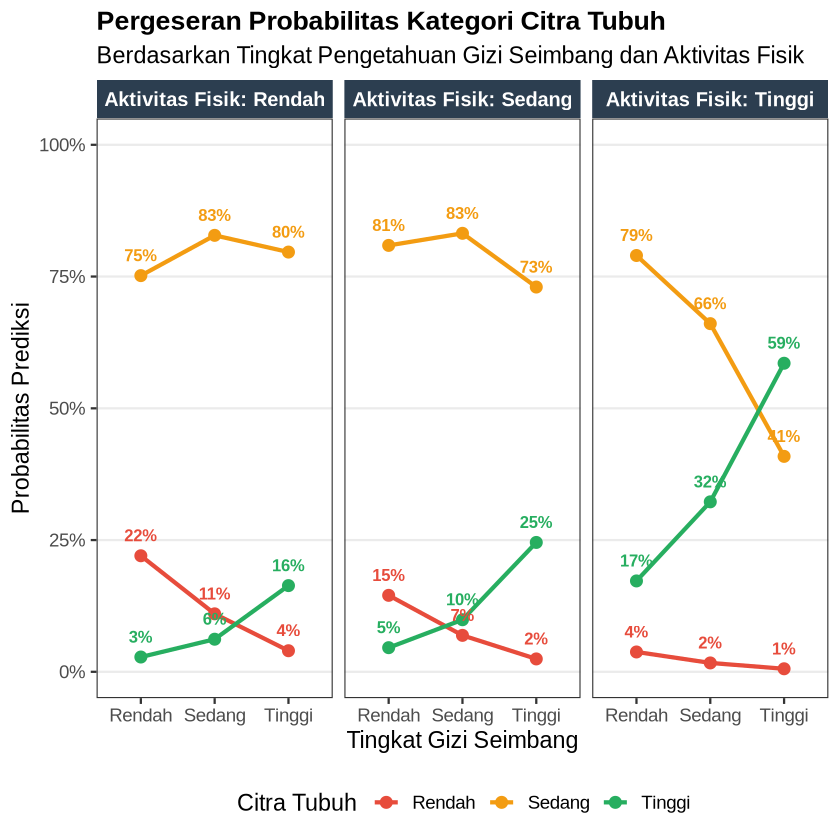

In [ ]:
library(ggeffects)
library(ggplot2)
library(scales)

# 1. Memprediksi dengan DUA variabel sekaligus
# Variabel pertama (gizi) akan menjadi sumbu X (kolom 'x')
# Variabel kedua (aktivitas) akan disimpan oleh ggeffects di kolom bernama 'group'
pred_gabungan_female <- ggpredict(model_ordinal_female, terms = c("gizi_seimbang_cat", "aktivitas_fisik_cat"))

# 2. Membuat Plot Gabungan (Faceted Plot)
plot_gabungan_female <- ggplot(pred_gabungan_female, aes(x = x, y = predicted, color = response.level, group = response.level)) +
  
  # Garis, Titik, dan Pita Interval
  geom_ribbon(aes(ymin = conf.low, ymax = conf.high, fill = response.level), 
              alpha = 0.1, color = NA, show.legend = FALSE) +
  geom_line(size = 1.2) +
  geom_point(size = 3) +
  
  # Label angka persentase
  geom_text(aes(label = percent(predicted, accuracy = 1)), 
            vjust = -1.2, size = 3.5, fontface = "bold", show.legend = FALSE) +
  
  # KUNCI UTAMA: Memecah plot berdasarkan Aktivitas Fisik (yang disimpan di kolom 'group')
  facet_wrap(~ group, labeller = labeller(group = function(x) paste("Aktivitas Fisik:", x))) +
  
  # Formatting Skala & Warna
  scale_y_continuous(labels = percent_format(accuracy = 1), limits = c(0, 1)) +
  scale_color_manual(values = c("Rendah" = "#e74c3c", "Sedang" = "#f39c12", "Tinggi" = "#27ae60")) +
  scale_fill_manual(values = c("Rendah" = "#e74c3c", "Sedang" = "#f39c12", "Tinggi" = "#27ae60")) +
  
  # Label & Tema
  labs(title = "Pergeseran Probabilitas Kategori Citra Tubuh",
       subtitle = "Berdasarkan Tingkat Pengetahuan Gizi Seimbang dan Aktivitas Fisik",
       x = "Tingkat Gizi Seimbang",
       y = "Probabilitas Prediksi",
       color = "Citra Tubuh") +
  # theme_bw (Black & White) sangat cocok untuk grafik berpanel (facet)
  theme_bw(base_size = 14) +
  theme(panel.grid.major.x = element_blank(),
        panel.grid.minor = element_blank(),
        strip.background = element_rect(fill = "#2c3e50", color = NA), # Latar belakang judul panel
        strip.text = element_text(color = "white", face = "bold", size = 12), # Teks judul panel
        plot.title = element_text(face = "bold", size = 16),
        legend.position = "bottom")

print(plot_gabungan_female)

In [ ]:
ggsave("../report/visualization/prob_plot_female.jpg", plot = plot_gabungan_female, width = 10, height = 6, units = "in", dpi = 1200)